# Stage 1: Single Hopf Oscillator


## The Model

A single uncoupled node obeys the Hopf normal form:

$$\dot{z} = z\,(\lambda + i\omega - |z|^2)$$

where $z = x + iy$, which expands to:

$$\dot{x} = x(\lambda - r^2) - \omega\, y$$
$$\dot{y} = y(\lambda - r^2) + \omega\, x$$

with $r^2 = x^2 + y^2$.

**Key behaviour:**
- $\lambda < 0$: stable fixed point at the origin — oscillations decay
- $\lambda = 0$: **Hopf bifurcation** (critical point)
- $\lambda > 0$: stable limit cycle with radius $|z| = \sqrt{\lambda}$ and angular frequency $\omega$



In [26]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src" / "hopf_model.py").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

FIG_DIR = ROOT / "figures" / "hopf model" / "single node"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from hopf_model import random_initial_conditions, simulate_hopf
from signal_processing import bandpass_filter, compute_phase

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


## 1. Simulate a single uncoupled oscillator

We use the general N-node solver with N=1, K=0 (no coupling), and a dummy 1×1 adjacency matrix.

In [27]:
def simulate_single(lam, omega_hz=10.0, z0=None, t_total=14.5, t_discard=1.0, fs=1250):
    """Simulate one uncoupled Hopf oscillator."""
    omega = 2 * np.pi * omega_hz
    if z0 is None:
        z0 = random_initial_conditions(1, rng=42)
    elif np.isscalar(z0):
        z0 = np.array([z0], dtype=complex)
    t, x, y = simulate_hopf(
        N=1, W=np.zeros((1, 1)), K=0.0, lam=lam, C=0.0,
        omega=np.array([omega]), z0=z0,
        t_total=t_total, t_discard=t_discard, fs=fs,
    )
    return t, x[0], y[0]

## 2. Time series for different $\lambda$

We simulate the oscillator for subcritical ($\lambda < 0$), critical ($\lambda = 0$),
and supercritical ($\lambda > 0$) regimes.

For $\lambda > 0$ the real part $x(t)$ settles onto a sinusoidal limit cycle with
amplitude $\sqrt{\lambda}$.

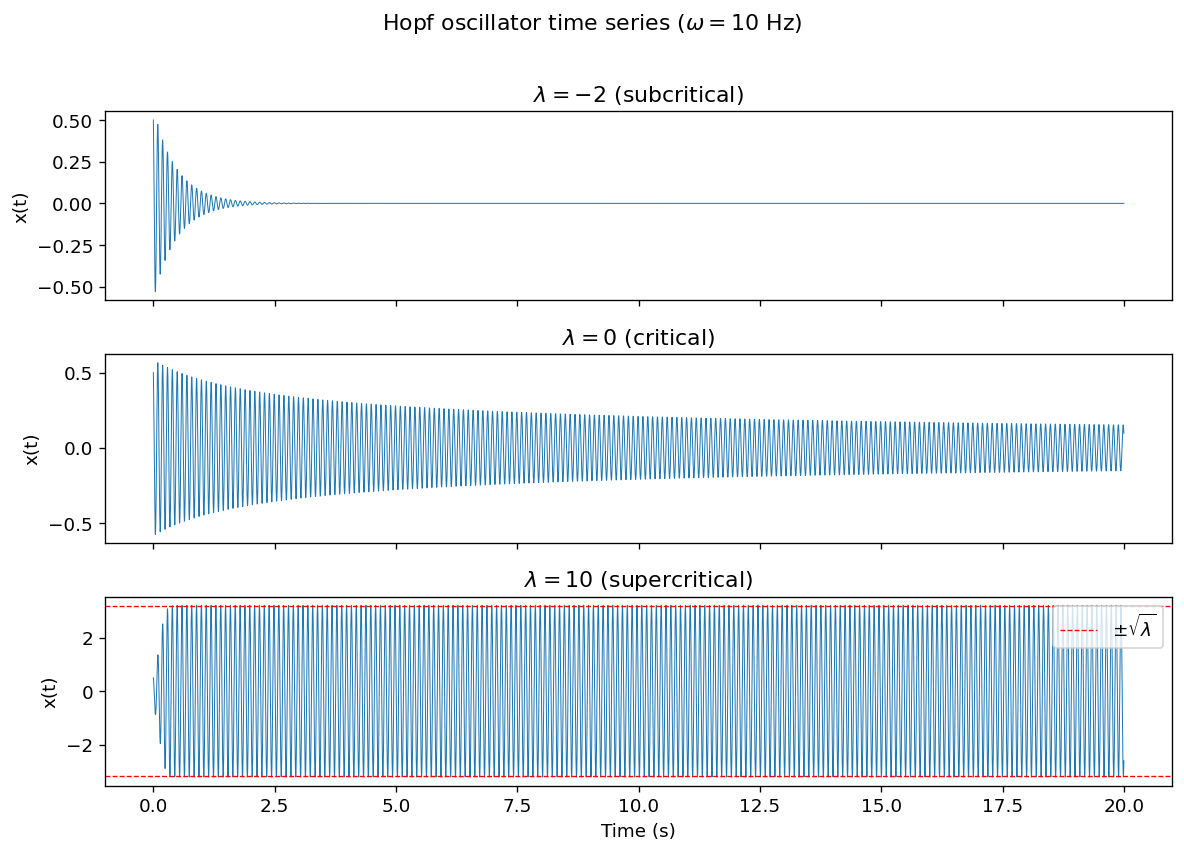

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

z0_start = np.array([0.5 + 0.3j])

for ax, lam, label in zip(axes, [-2.0, 0.0, 10.0],
                          [r"$\lambda = -2$ (subcritical)",
                           r"$\lambda = 0$ (critical)",
                           r"$\lambda = 10$ (supercritical)"]):
    t, x, y = simulate_single(lam, z0=z0_start, t_discard=0.0,t_total=20)
    ax.plot(t, x, linewidth=0.6)
    ax.set_ylabel("x(t)")
    ax.set_title(label)
    if lam > 0:
        ax.axhline(np.sqrt(lam), color="red", ls="--", lw=0.8, label=r"$\pm\sqrt{\lambda}$")
        ax.axhline(-np.sqrt(lam), color="red", ls="--", lw=0.8)
        ax.legend(loc="upper right")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Hopf oscillator time series ($\\omega = 10$ Hz)", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_time_series_lambda.png", dpi=300, bbox_inches="tight")


### Observations

- **Subcritical ($\lambda = -2$):** The oscillation decays exponentially to zero. The fixed point at the origin is stable, so any initial perturbation dies out — the node is effectively silent.
- **Critical ($\lambda = 0$):** The decay is much slower (algebraic rather than exponential). The system sits at the boundary between damped and sustained oscillation, which in the full brain model corresponds to the edge of criticality.
- **Supercritical ($\lambda = 10$):** After a brief transient the signal settles into a stable sinusoid bounded by $\pm\sqrt{\lambda} \approx \pm 3.16$ (red dashed lines). This is the limit cycle predicted by the Hopf normal form — amplitude is set entirely by $\lambda$, while the frequency is set by $\omega$.

## 3. Phase portraits

Plotting the trajectory in the $(x, y)$ plane shows:
- **Subcritical**: spiral into the origin
- **Critical**: slow decay toward zero
- **Supercritical**: spiral outward onto a circle of radius $\sqrt{\lambda}$

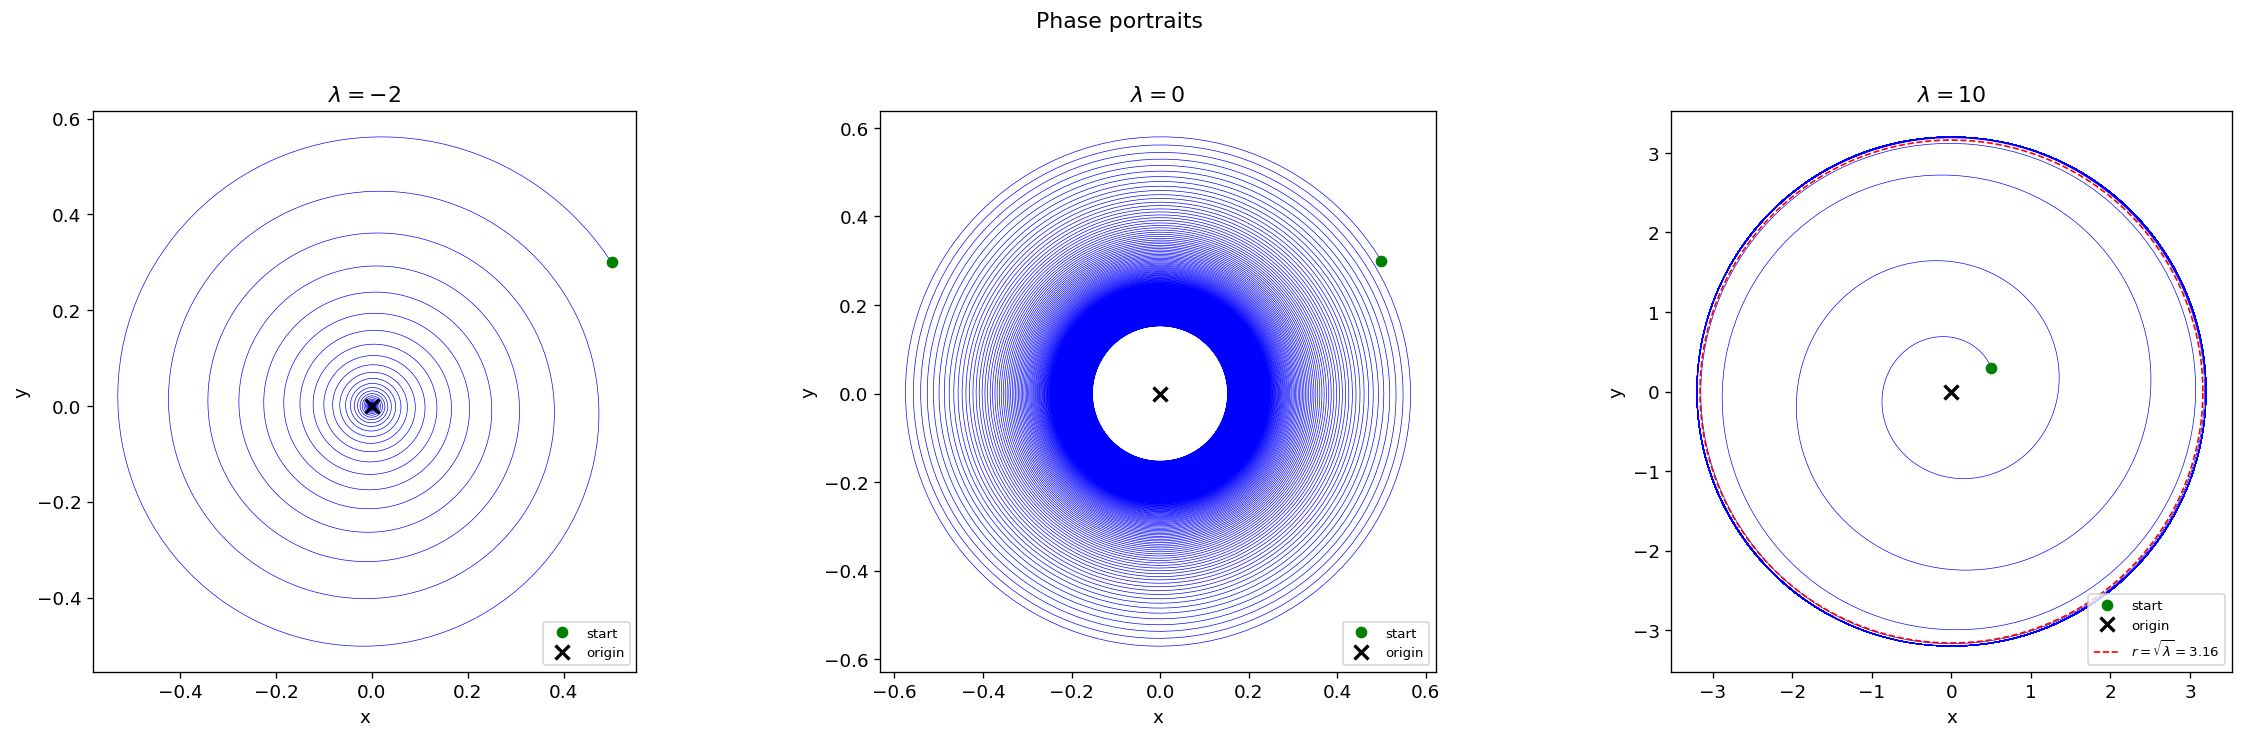

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

z0_start = np.array([0.5 + 0.3j])

for ax, lam, title in zip(axes, [-2.0, 0.0, 10.0],
                          [r"$\lambda=-2$", r"$\lambda=0$", r"$\lambda=10$"]):
    t, x, y = simulate_single(lam, z0=z0_start, t_total=20.0, t_discard=0.0)
    ax.plot(x, y, linewidth=0.4, color="blue")
    ax.plot(x[0], y[0], "go", ms=6, label="start")
    ax.plot(0, 0, "kx", ms=8, mew=2, label="origin")
    if lam > 0:
        theta_circle = np.linspace(0, 2 * np.pi, 200)
        r = np.sqrt(lam)
        ax.plot(r * np.cos(theta_circle), r * np.sin(theta_circle),
               "r--", lw=1, label=rf"$r=\sqrt{{\lambda}}={r:.2f}$")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower right")

fig.suptitle("Phase portraits", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_phase_portraits.png", dpi=300, bbox_inches="tight")


## 4. Bifurcation diagram

We plot $\lambda$ from $-5$ to $+50$ and measure the steady-state amplitude
$|z|_{\text{ss}}$.

C:\Users\Bob Rice\AppData\Local\Temp\ipykernel_18744\1342964766.py:12: RuntimeWarning: invalid value encountered in sqrt
  theory = np.where(lam_values > 0, np.sqrt(lam_values), 0.0)


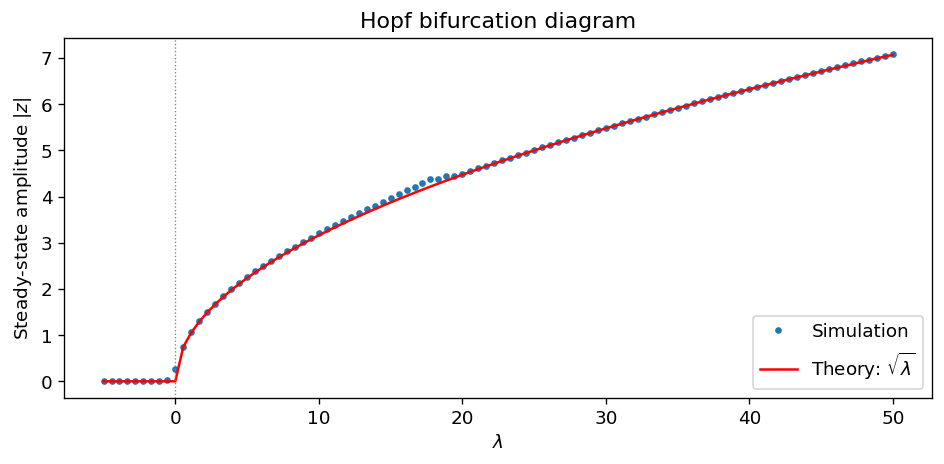

In [30]:
lam_values = np.linspace(-5, 50, 100)
amplitudes = []

z0_start = np.array([0.5 + 0.3j])

for lam in lam_values:
    t, x, y = simulate_single(lam, z0=z0_start, t_total=6.0, t_discard=4.0)
    r = np.sqrt(x**2 + y**2)
    amplitudes.append(np.mean(r[-len(r)//4:]))  # average over last quarter

amplitudes = np.array(amplitudes)
theory = np.where(lam_values > 0, np.sqrt(lam_values), 0.0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lam_values, amplitudes, "o", ms=3, label="Simulation")
ax.plot(lam_values, theory, "r-", lw=1.5, label=r"Theory: $\sqrt{\lambda}$")
ax.axvline(0, color="grey", ls=":", lw=0.8)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"Steady-state amplitude $|z|$")
ax.set_title("Hopf bifurcation diagram")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "03_bifurcation_diagram.png", dpi=300, bbox_inches="tight")


## 5. Amplitude depends on $\lambda$, frequency does not

An important property: for $\lambda > 0$, changing $\lambda$ changes the **amplitude**
of the limit cycle ($\sqrt{\lambda}$) but not the **frequency** (which is set by $\omega$).
This is why the paper's rescaling $\tilde{x}_i = \sqrt{\lambda}\, x_i$ normalises
the limit-cycle radius to 1.

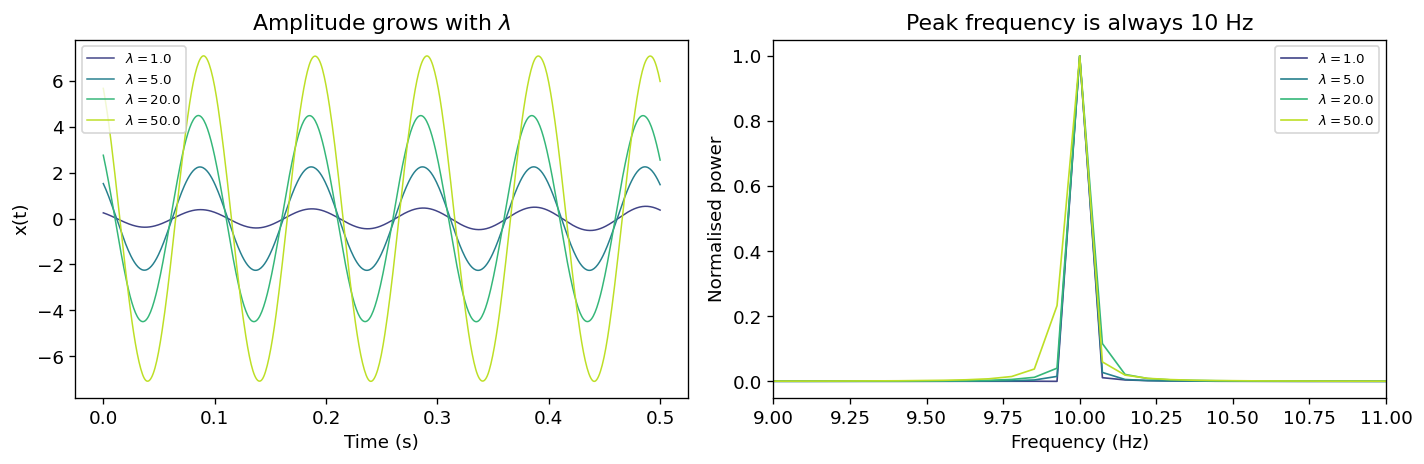

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lam_test = [1.0, 5.0, 20.0, 50.0]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(lam_test)))

for lam, col in zip(lam_test, colors):
    t, x, y = simulate_single(lam, omega_hz=10.0, z0=np.array([0.1 + 0.1j]))

    # Time series (show 0.5 s window)
    win = t <= 0.5
    axes[0].plot(t[win], x[win], color=col, lw=0.9, label=rf"$\lambda={lam}$")

    # Power spectrum
    freqs = np.fft.rfftfreq(len(x), d=1.0 / 1250)
    power = np.abs(np.fft.rfft(x)) ** 2 / len(x)
    fmask = (freqs >= 5) & (freqs <= 15)
    axes[1].plot(freqs[fmask], power[fmask] / power[fmask].max(),
                 color=col, lw=1, label=rf"$\lambda={lam}$")

axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("x(t)")
axes[0].set_title("Amplitude grows with $\\lambda$")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Normalised power")
axes[1].set_title("Peak frequency is always 10 Hz")
axes[1].set_xlim(9, 11)
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "04_amplitude_and_fft.png", dpi=300, bbox_inches="tight")


## 7. Signal processing pipeline

In later stages we will compare simulated and empirical functional connectivity
via the **phase-lag index (PLI)**.

1. Simulate $x(t)$ (the "MEG signal")
2. Butterworth bandpass filter into the alpha band (8–12 Hz)
3. Hilbert transform to extract instantaneous phase $\theta(t)$



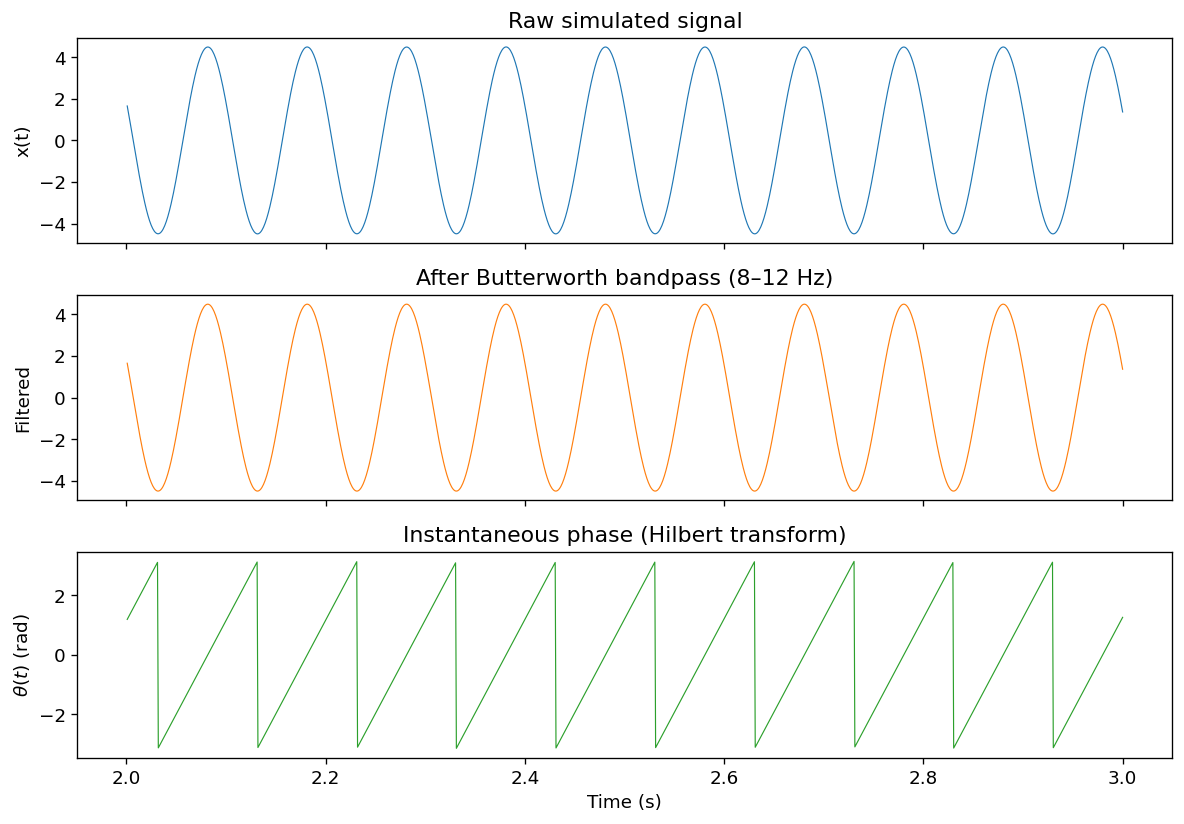

In [32]:
lam = 20.0
omega_hz = 10.0
fs = 1250

t, x, y = simulate_single(lam, omega_hz=omega_hz, z0=np.array([0.1 + 0.1j]))

x_filt = bandpass_filter(x, fs, low=8.0, high=12.0)
phase = compute_phase(x, fs, low=8.0, high=12.0)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

win = (t >= 2.0) & (t <= 3.0)  # 1 s window

axes[0].plot(t[win], x[win], lw=0.7)
axes[0].set_ylabel("x(t)")
axes[0].set_title("Raw simulated signal")

axes[1].plot(t[win], x_filt[win], lw=0.7, color="C1")
axes[1].set_ylabel("Filtered")
axes[1].set_title("After Butterworth bandpass (8–12 Hz)")

axes[2].plot(t[win], phase[win], lw=0.7, color="C2")
axes[2].set_ylabel(r"$\theta(t)$ (rad)")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Instantaneous phase (Hilbert transform)")

fig.tight_layout()
fig.savefig(FIG_DIR / "05_signal_pipeline.png", dpi=300, bbox_inches="tight")


## 8. Transient timescale depends on $\lambda$

The supplementary material shows that, after rescaling by $\sqrt{\lambda}$, the
excitability parameter $\lambda$ becomes the **timescale of amplitude dynamics**.
Higher $\lambda$ means faster convergence to the limit cycle.

This is relevant for the paper's choice to discard the first 1 s of simulation.

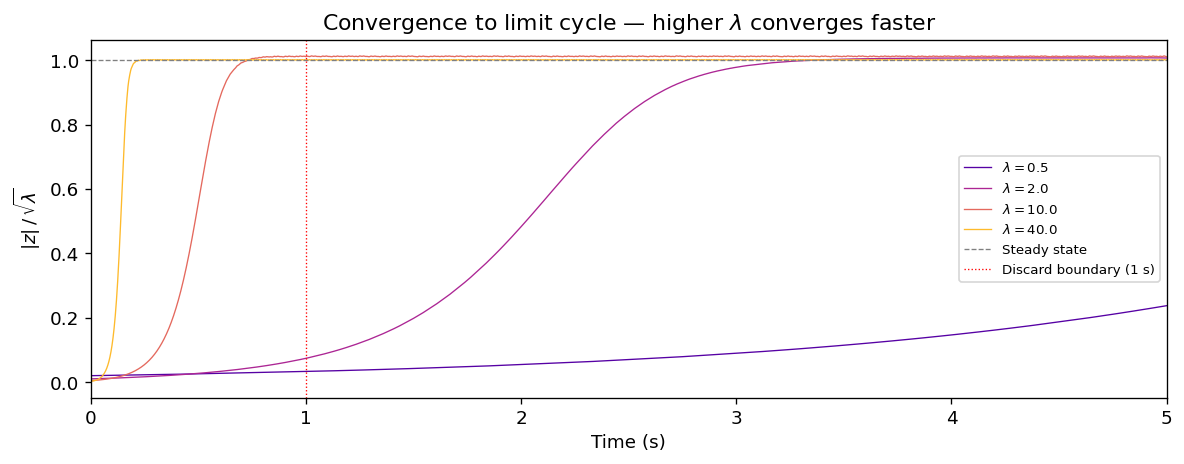

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))

z0_small = np.array([0.01 + 0.01j])  # start far from limit cycle

for lam, col in zip([0.5, 2.0, 10.0, 40.0],
                     plt.cm.plasma(np.linspace(0.15, 0.85, 4))):
    t, x, y = simulate_single(lam, omega_hz=10.0, z0=z0_small,
                              t_total=5.0, t_discard=0.0)
    r = np.sqrt(x**2 + y**2)
    r_norm = r / np.sqrt(lam)  # normalise by theoretical steady-state
    ax.plot(t, r_norm, color=col, lw=0.8, label=rf"$\lambda={lam}$")

ax.axhline(1.0, color="grey", ls="--", lw=0.8, label="Steady state")
ax.axvline(1.0, color="red", ls=":", lw=0.8, label="Discard boundary (1 s)")
ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$|z| \,/\, \sqrt{\lambda}$")
ax.set_title("Convergence to limit cycle — higher $\\lambda$ converges faster")
ax.set_xlim(0, 5)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_normalized_convergence.png", dpi=300, bbox_inches="tight")


## 9. Multiple initial conditions

The paper averages results over many random initial conditions sampled uniformly
in the unit disk. Here we verify that all trajectories converge to the same
limit cycle, differing only in phase.

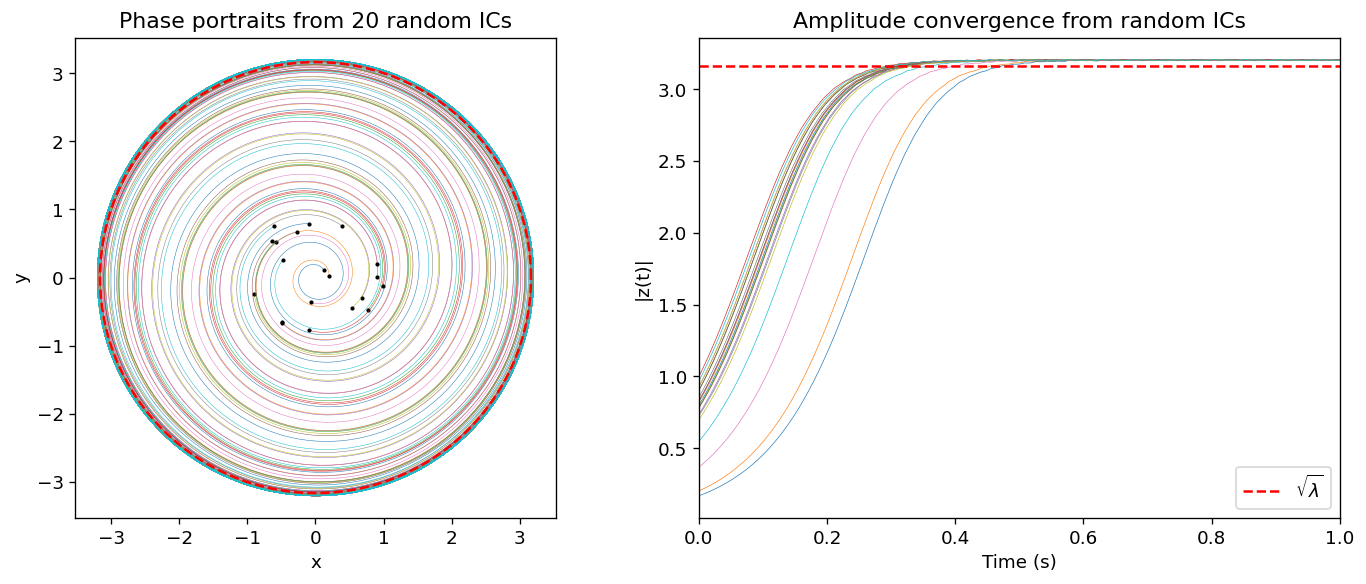

In [34]:
lam = 10.0
n_ics = 20
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i in range(n_ics):
    z0 = random_initial_conditions(1, rng=rng)
    t, x, y = simulate_single(lam, omega_hz=10.0, z0=z0,
                              t_total=3.0, t_discard=0.0)
    axes[0].plot(x, y, lw=0.3, alpha=1)
    axes[0].plot(x[0], y[0], "k.", ms=3)

theta_c = np.linspace(0, 2 * np.pi, 200)
r = np.sqrt(lam)
axes[0].plot(r * np.cos(theta_c), r * np.sin(theta_c), "r--", lw=1.5,)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
axes[0].set_title(f"Phase portraits from {n_ics} random ICs")

# Show convergence of amplitude
rng2 = np.random.default_rng(0)
for i in range(n_ics):
    z0 = random_initial_conditions(1, rng=rng2)
    t, x, y = simulate_single(lam, omega_hz=10.0, z0=z0,
                              t_total=3.0, t_discard=0.0)
    axes[1].plot(t, np.sqrt(x**2 + y**2), lw=0.4, alpha=1)

axes[1].axhline(np.sqrt(lam), color="r", ls="--", lw=1.5, label=r"$\sqrt{\lambda}$")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("|z(t)|")
axes[1].set_title("Amplitude convergence from random ICs")
axes[1].legend()
axes[1].set_xlim(0,1)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_random_ic_amplitude.png", dpi=300, bbox_inches="tight")


## Summary

| Observation | Details |
|---|---|
| **Hopf bifurcation** | For $\lambda < 0$ the origin is stable and oscillations decay; for $\lambda > 0$ a stable limit cycle appears with radius $|z| \approx \sqrt{\lambda}$ |
| **Time series** | Subcritical ($\lambda < 0$): decaying oscillations; critical ($\lambda = 0$): marginal; supercritical ($\lambda > 0$): sustained oscillations at amplitude $\sqrt{\lambda}$ |
| **Phase portraits** | Subcritical: trajectories spiral into the origin; supercritical: trajectories close onto a circular limit cycle in the $(x, y)$ plane |
| **Bifurcation diagram** | Simulated steady-state amplitude matches the pitchfork scaling $|z| \sim \sqrt{\lambda}$ for $\lambda > 0$ |
| **Amplitude vs frequency** | Amplitude grows with $\lambda$, but the dominant frequency in the spectrum remains set by $\omega$ (not by $\lambda$) |
| **Signal pipeline** | Raw $x(t)$ $\to$ bandpass (e.g. 8–12 Hz) $\to$ Hilbert instantaneous phase $\theta(t)$, as used later for phase-based connectivity |
| **Transient timescale** | After discarding an initial window, larger $\lambda$ typically yields faster convergence onto the limit cycle |
| **Initial conditions** | Random starts in the unit disk all approach the same limit-cycle amplitude but can differ in early transients—motivating averaging in the paper |

